**Ryan v2 variant:** consumes extended spectra written by notebook 6 (`*_ryanv2`) under `Outputs/<SN>/twodim_ryanv2/` (classic `twodim/` unaffected). Re-mangled intermediates go under `.../<product>/RE_mangled_spectra_2dim/`; FINAL spectra under `FINAL_spectra_2dim/twodim_ryanv2/...` (see `remangled_spectra_path` / `final_spectra_path_2dim` in cell 1).

# RE-MANGLE spectra
We need to re-mangle spectra because what we did in the 2dim fitting is "in principle" wrong.

In the 2dim grid we compared synthetic photometry @ average filter wavelength with Flux spectral density.
You should use eff wavelength, which is avg filter wavelength weighted for the underlying SED.

Now that we have extrapolated an approximated estimate of the underlying SEDs we need to iterativly warp&re-measure eff wvl of the SED until observed photometry and synthesized photometry is matching.

Read Section 2.2.2 of the paper if you are confused!!

    

In [1]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/4_LCs_late_extrapolated/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

OUTPUT_DIR = COCO_PATH+"Outputs/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
import what_the_flux as wtf
sys.path.insert(0, COCO_PATH+'Codes/')
import rimangle_log_spectrum as rml
import pipeline_config as pconf
# Match notebook 6: spec_class.mode ('extend_spectra' | 'extrapolate_spectra') and dual product (spliced | full_gp).
TWODIM_GP_MODE_RIMANGLE = 'extrapolate_spectra'
TWODIM_PRODUCT_RIMANGLE = pconf.SUBDIR_FULL_GP


def twodim_extended_spectra_path(sn):
    return pconf.twodim_ryanv2_product_dir(OUTPUT_DIR, sn, TWODIM_GP_MODE_RIMANGLE, TWODIM_PRODUCT_RIMANGLE) + '/'


def final_spectra_path_2dim(sn):
    if pconf.USE_LEGACY_TWODIM_LAYOUT:
        base = pconf.final_spectra_branch_dir(COCO_PATH.rstrip(os.sep), sn, twodim_branch=None)
    else:
        br = pconf.twodim_ryanv2_final_branch(
            pconf.twodim_mode_to_short(TWODIM_GP_MODE_RIMANGLE),
            TWODIM_PRODUCT_RIMANGLE,
        )
        base = pconf.final_spectra_branch_dir(COCO_PATH.rstrip(os.sep), sn, twodim_branch=br)
    return base + os.sep


def remangled_spectra_path(sn):
    """Re-mangled spectra/plots: under ``twodim_ryanv2/.../<product>/RE_mangled_spectra_2dim`` (or legacy ``*_ryanv2`` dirname)."""
    return (
        pconf.twodim_ryanv2_remangled_dir(
            OUTPUT_DIR, sn, TWODIM_GP_MODE_RIMANGLE, TWODIM_PRODUCT_RIMANGLE
        ).rstrip(os.sep)
        + os.sep
    )


In [2]:
import numpy as np
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import pandas as pd
from astropy.io import fits
from scipy import interpolate
from scipy import integrate
import scipy.optimize as opt
import sncosmo

import matplotlib.cm as cm
import scipy
from itertools import cycle

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

import astropy.units as u
%matplotlib inline

In [3]:
### I NEED TO ASSUME SOME COSMOLOGY IF I WANT TO GET ABSOLUTE FLUX TEMPLATES (AS IF THEY WERE AT 10pc)
import astropy.cosmology
mycosmo = astropy.cosmology.FlatLambdaCDM(Om0=0.3, H0=70)

In [4]:
color_dict = {'Bessell_U': 'blue', 'Bessell_B': 'royalblue','Bessell_V':  'limegreen',
              'Bessell_R':  'red', 'Bessell_I':  'mediumvioletred',
              'sdss_g':'darkgreen','ptf_g':'darkgreen', "sdss_g'":'darkgreen','sdss_i':'indianred',
              "sdss_i'":'indianred','sdss_r': 'darkred', "sdss_r'":'darkred','sdss_z':'sienna', "sdss_z'":'sienna',
              'sdss_u': 'darkblue', "sdss_u'": 'darkblue', 'Y':'salmon','H':'darkred', 'J':  'k',
              'Ks':  'brown','K':  'brown', 'swift_UVW1':'indigo', 'swift_UVW2':'darkblue',
               'swift_UVM2':'darkmagenta','swift_U':'plum','swift_V':'teal','swift_B':'powderblue'}

mark_dict = {'Bessell_U': 'o','Bessell_B': 'o', 'Bessell_V':'o', 'Bessell_R':'o', 'Bessell_I': 'o', 
             'sdss_g':'s','ptf_g':'s', "sdss_g'":'s', 'sdss_i':'s', "sdss_i'":'s',
                'sdss_r':'s', "sdss_r'":'s', 'sdss_z':'s', "sdss_z'":'s', 'sdss_u': 's', "sdss_u'": 's',
                'Y':  'o','H':  'o', 'J':  'o', 'Ks':  'o','K':  'o',
                'swift_UVW1':'D', 'swift_UVW2':'D', 'swift_UVM2':'D', 'swift_U':'D',
                'swift_V':'D', 'swift_B':'D'}

CSP_SNe = ['SN2004fe', 'SN2005bf', 'SN2006V', 'SN2007C', 'SN2007Y',
           'SN2009bb',  'SN2008aq', 'SN2006T', 'SN2004gq', 'SN2004gt',
           'SN2004gv','SN2006ep', 'SN2008fq', 'SN2006aa']

#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y']

convert2mjd = (lambda x: float(x.replace('_spec_extended.txt','')\
                               .replace('_spec_extended_FL.txt','')\
                               .replace('_spec_extended_SMOOTH.txt','')))

#exclude_filt = ['H','Ks', 'J', 'K']

In [5]:
color_dict = {
    # Existing matches from your example
    'Swope_i': 'indianred',
    'FourStar_H': 'darkred',
    'FourStar_J': 'black',
    'DECam_i': 'orangered',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FourStar_Ks': 'brown',
    'UVOT_U': 'teal',
    'Skymapper_i': 'slateblue',
    'Sinistro_g': 'darkgreen',
    'Sinistro_r': 'crimson',
    'Skymapper_r': 'deeppink',
    'Skymapper_g': 'forestgreen',
    'EFOSC2_V': 'limegreen',
    'Sinistro_i': 'firebrick',
    'DECam_r': 'darkorange',
    'DECam_g': 'mediumspringgreen',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'FourStar_J1': 'dimgray',
    'Swope_B': 'royalblue',
    'Swope_r': 'red',
    'Swope_g': 'darkseagreen',
    'EFOSC2_U': 'blue',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_z': 'sienna',
    'IMACS_r': 'darkred',
    'LRIS_I': 'mediumvioletred',
    'SOFI_H': 'firebrick',
    'SOFI_Ks': 'saddlebrown',

    # New assignments (color-coded by band)
    'VISTA_Ks': 'saddlebrown',
    'VISTA_J': 'dimgray',
    'VISTA_Y': 'salmon',
    'FLAMINGOS-2_Ks': 'sienna',
    'UVOT_M2': 'darkviolet',
    'UVOT_W1': 'purple',
    'UVOT_W2': 'indigo',
    'HSC_z': 'darkslategray',
    'GFC_i': 'firebrick',
    'GFC_y': 'goldenrod',
    'GFC_z': 'maroon',
    'GFC_r': 'tomato',
    'SIRIUS_H': 'darkred',
    'SIRIUS_J': 'black',
    'SIRIUS_Ks': 'brown',
    'T80Cam_g': 'seagreen',
    'GROND_H': 'maroon',
    'GROND_J': 'dimgray',
    'GROND_K': 'saddlebrown',
    'GROND_g': 'mediumseagreen',
    'GROND_i': 'orangered',
    'GROND_r': 'crimson',
    'GROND_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FLAMINGOS-2_H': 'firebrick',
    'IMACS_i': 'orangered',
    'FLAMINGOS-2_J': 'black',
    'UVOT_B': 'dodgerblue',
    'GMOS_g': 'green',
    'GMOS_i': 'indianred',
    'GMOS_r': 'red',
    'GMOS_z': 'darkslategray',
    'FORS2_R': 'crimson',
    'VIMOS_z': 'maroon',
    'FORS2_I': 'mediumvioletred',
    'FORS2_B': 'blue',
    'FORS2_V': 'limegreen',
    'ANDICAM_K': 'brown',
    'MOIRCS_Ks': 'sienna',
    'HAWKI_Ks': 'brown'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

mark_dict = {
    # Swope (Circle)
    'Swope_i': 'o',
    'Swope_V': 'o',
    'Swope_B': 'o',
    'Swope_r': 'o',
    'Swope_g': 'o',

    # FourStar (Circle)
    'FourStar_H': 'o',
    'FourStar_J': 'o',
    'FourStar_Ks': 'o',
    'FourStar_J1': 'o',
    'FourStar_Ks': 'o',

    # VISTA (Circle - keeping consistent with other IR survey survey data)
    'VISTA_Ks': 'o',
    'VISTA_J': 'o',
    'VISTA_Y': 'o',

    # SOFI (Circle)
    'SOFI_H': 'o',
    'SOFI_Ks': 'o',

    # ANDICAM (Circle)
    'ANDICAM_K': 'o',

    # DECam (Triangle Up)
    'DECam_i': '^',
    'DECam_z': '^',
    'DECam_Y': '^',
    'DECam_r': '^',
    'DECam_g': '^',
    'DECam_u': '^',

    # HSC (Triangle Right - distinct from DECam but similar large imager)
    'HSC_z': '>',

    # MOIRCS (Triangle Right - Subaru)
    'MOIRCS_Ks': '>',

    # FLAMINGOS-2 (Triangle Down - Gemini IR)
    'FLAMINGOS-2_Ks': 'v',
    'FLAMINGOS-2_H': 'v',
    'FLAMINGOS-2_J': 'v',

    # GMOS (Triangle Left - Gemini Optical)
    'GMOS_g': '<',
    'GMOS_i': '<',
    'GMOS_r': '<',
    'GMOS_z': '<',

    # FORS2 (Triangle Left - VLT)
    'FORS2_R': '<',
    'FORS2_I': '<',
    'FORS2_B': '<',
    'FORS2_V': '<',

    # VIMOS (Triangle Left - VLT)
    'VIMOS_z': '<',

    # HAWKI (Triangle Left - VLT)
    'HAWKI_Ks': '<',

    # UVOT (Cross)
    'UVOT_M2': 'X',
    'UVOT_W1': 'X',
    'UVOT_U': 'X',
    'UVOT_W2': 'X',
    'UVOT_B': 'X',

    # GFC / Pan-STARRS (Pentagon)
    'GFC_i': 'p',
    'GFC_y': 'p',
    'GFC_z': 'p',
    'GFC_r': 'p',

    # Skymapper (Plus Filled)
    'Skymapper_i': 'P',
    'Skymapper_r': 'P',
    'Skymapper_g': 'P',

    # Sinistro (Square)
    'Sinistro_g': 's',
    'Sinistro_r': 's',
    'Sinistro_i': 's',
    'Sinistro_V': 's',
    'Sinistro_z': 's',

    # IMACS (Square)
    'IMACS_i': 's',
    'IMACS_r': 's',

    # SIRIUS (Diamond - grouped with other medium aperture IR like SOFI/RetroCam? or Diamond like EFOSC2)
    'SIRIUS_H': 'D',
    'SIRIUS_J': 'D',
    'SIRIUS_Ks': 'D',

    # EFOSC2 (Diamond)
    'EFOSC2_V': 'D',
    'EFOSC2_U': 'D',

    # LRIS (Diamond)
    'LRIS_I': 'D',

    # T80Cam (Star - distinct small survey)
    'T80Cam_g': '*',

    # GROND (Hexagon - multi-channel instrument)
    'GROND_H': 'h',
    'GROND_J': 'h',
    'GROND_K': 'h',
    'GROND_g': 'h',
    'GROND_i': 'h',
    'GROND_r': 'h',
    'GROND_z': 'h'
}

In [6]:
info_objects = pd.read_csv(DATAINFO_PATH+'info.dat', comment='#', delimiter=' ')

In [7]:
def calc_lam_eff(wls, transmission, flux):
    return (integrate.trapezoid(transmission*flux*wls, wls)/\
            integrate.trapezoid(transmission*flux, wls))

def prop_err_div(x,y,sig_x,sig_y):
    return ((sig_x/y)**2  +  ((x*sig_y)/y**2)**2 )**0.5

In [8]:
import numpy as np

class ReMangle_SingleSpectrumClass():
    """Class to load and mangle a single spectrum:
    """
    
    def __init__(self, snname, twodim=True, spec_file=None, verbose=False, extended_flux_in_log10=None, save_flux_in_log10=True):
        """
        extended_flux_in_log10: None=auto (NB6 newlog: linear Å, log10 F on disk), True/False=override.
        save_flux_in_log10: if True and extended was log10, REmangled output columns are log10 F / dex (same as extended files).
        """
        ## Initialise the class variables            
        self.snname = snname
        self.extended_flux_in_log10 = extended_flux_in_log10
        self.save_flux_in_log10 = bool(save_flux_in_log10)
        self.check_results_folder()
        self.extension_type='2dim' if twodim else 'classic'
        self.create_FINALspec_folder()

        # Load min/max MJD dictionary for filters
        mjd_dict_path = '/Users/ravkaur/Desktop/research/kilonova-SED/AT2017gfo_mjd_ranges_dict.json'
        with open(mjd_dict_path, 'r') as f:
            self.filter_mjd_dict = json.load(f)
        
        if spec_file is None:
            print ("Choose one spec_file from this list:")
            print (self.get_spec_list())
        else:
            self.spec_file = spec_file
            print ('self.spec_file', self.spec_file)
            self.load_manglingfile()
        self.load_final_info()

    def check_results_folder(self):
        results_directory = OUTPUT_DIR+'/%s/'%self.snname
        if not os.path.exists(results_directory):
            print ("I cant mangle a spectrum if I theres no fitted LC yet")
        else: self.results_mainpath = results_directory

    def check_extended_file(self):
        if self.extension_type == '2dim':
            mangled_file_path = twodim_extended_spectra_path(self.snname) + self.spec_file
        else:
            mangled_file_path = OUTPUT_DIR+'/%s/extended_spectra/%s'%(self.snname,\
                                                                                      self.spec_file)
        if not os.path.isfile(mangled_file_path):
            print ("Sorry, This object %s has not mangled file"%mangled_file_path)
        else: 
            self.mangled_file_path = mangled_file_path

    def _output_numeric_stem(self):
        """Filename stem (%.6f) for default TwoD outputs: same as extended file (GP log phase or MJD), *not* spec_mjd."""
        s = str(self.spec_file)
        for suff in (
            '_spec_extended_SNF.txt',
            '_spec_extended_SMOOTH.txt',
            '_spec_extended_FL.txt',
            '_spec_extended.txt',
        ):
            if s.endswith(suff):
                return float(s[: -len(suff)])
        raise ValueError('Unrecognized spec_file for output stem: %r' % s)

    def get_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended.txt' in f]
        return onlyfiles

    def check_spec_manglingphot(self):
        all_specs = self.get_spec_list()
        mangling_file = self.results_mainpath+'fitted_phot4mangling_%s.dat'%self.snname
        phot4mangling = pd.read_csv(mangling_file, sep='\t')
        for spec_file in all_specs:
            file_mjd = float(spec_file.replace('_spec_extended.txt',''))
            mask = phot4mangling['spec_mjd'].values == file_mjd
            if len(phot4mangling[mask])==0:
                print ('There.s no magnling photometry fro this. Are you sure nothing went wrong?', spec_file)
                print ('I compared', phot4mangling['spec_mjd'].values ,file_mjd)

    def get_FLAGGED_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended_FL.txt' in f]
        return onlyfiles

    def get_SMOOTH_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended_SMOOTH.txt' in f]
        return onlyfiles


    def get_SNF_spec_list(self, verbose=False):
        if self.extension_type == '2dim':
            extended_files_path = twodim_extended_spectra_path(self.snname)
        else:
            extended_files_path = OUTPUT_DIR+'/%s/extended_spectra/'%(self.snname)

        self.extended_files_path = extended_files_path
        onlyfiles = [f for f in os.listdir(extended_files_path) \
                         if os.path.isfile(os.path.join(extended_files_path, f)) if 'extended_SNF.txt' in f]
        return onlyfiles

    
    def load_original_phot(self, verbose = False):
        path_log = os.path.join(OUTPUT_DIR+'/%s/fitted_phot_logspace_%s.dat'%(self.snname,self.snname))
        path_lin = os.path.join(OUTPUT_DIR+'/%s/fitted_phot_%s.dat'%(self.snname,self.snname))
        if os.path.isfile(path_log):
            lc_pd = pd.read_csv(path_log, sep='\t')
        elif os.path.isfile(path_lin):
            lc_pd = pd.read_csv(path_lin, sep='\t')
        else:
            raise FileNotFoundError('No fitted_phot_logspace_%s.dat or fitted_phot_%s.dat in %s'%(self.snname,self.snname,OUTPUT_DIR))
        self.original_phot = lc_pd
        return lc_pd
    
    def _t0_fix_for_sn(self):
        """Same convention as 4_LCfit_KN_log: t0_fix = MJD[0] - Phase[0] on late-extrap LC."""
        p = DATALC_PATH + '%s.dat' % self.snname
        d = np.genfromtxt(p, dtype=None, encoding='utf-8', names=True)
        return float(d['MJD'][0] - d['Phase'][0])

    def _synthetic_phot4mangling_from_logspace(self, file_key):
        """TwoD FL filenames use GP grid key; mangle has one row per observed spectrum. Build one row from fitted_phot_logspace."""
        mpath = self.results_mainpath + 'fitted_phot4mangling_%s.dat' % self.snname
        lpath = self.results_mainpath + 'fitted_phot_logspace_%s.dat' % self.snname
        if not (os.path.isfile(mpath) and os.path.isfile(lpath)):
            return pd.DataFrame()
        lp = pd.read_csv(lpath, sep='\t')
        if 'Log_Phase' not in lp.columns or len(lp) < 1:
            return pd.DataFrame()
        fk = float(file_key)
        lpv_col = lp['Log_Phase'].astype(float)
        # Nearest row on the global 2D grid (NB6 save uses %.6f; logspace has full float — often match within 2e-4,
        # but can differ by ~0.003–0.01 when 6dp rounding vs exact grid do not line up; allow one grid cell.)
        _pv = lpv_col.to_numpy()
        pos = int(np.argmin(np.abs(_pv - fk)))
        min_d = float(np.abs(_pv[pos] - fk))
        if min_d > 0.01:
            return pd.DataFrame()
        row = lp.iloc[[pos], :]
        lpv = float(row['Log_Phase'].iloc[0])
        t0f = self._t0_fix_for_sn()
        smjd = t0f + 10.0**lpv
        templ = pd.read_csv(mpath, sep='\t', nrows=0)
        r0 = {c: np.nan for c in templ.columns}
        r0['spec_file'] = self.spec_file
        r0['spec_mjd'] = smjd
        r0['ext_grid_phase'] = lpv
        r0['spec_log_phase'] = lpv
        for c in row.columns:
            if c == 'Log_Phase':
                continue
            if c.endswith('_log_flux_err'):
                filt = c.replace('_log_flux_err', '')
                key = filt + '_fit_log_fluxerr'
            elif c.endswith('_log_flux'):
                filt = c.replace('_log_flux', '')
                key = filt + '_fit_log_flux'
            else:
                continue
            if key in r0:
                v = row[c].iloc[0]
                r0[key] = float(v) if np.isfinite(v) else np.nan
        for c in list(templ.columns):
            if not str(c).endswith('_inrange'):
                continue
            fbase = str(c).replace('_inrange', '')
            fcol = fbase + '_fit_log_flux'
            if fcol in r0 and np.isfinite(r0.get(fcol, np.nan)):
                r0[c] = True
            else:
                r0[c] = False
        return pd.DataFrame([r0])

    def _match_mangle_row(self, phot4mangling, file_key):
        file_key = float(file_key)
        n = len(phot4mangling)
        if n == 0:
            return phot4mangling
        m = np.zeros(n, dtype=bool)
        if 'ext_grid_phase' in phot4mangling.columns:
            v = phot4mangling['ext_grid_phase'].values.astype(float)
            # 1e-3: stem from %.6f vs table float; 6dp tie-break for same grid
            m |= np.isclose(v, file_key, rtol=0.0, atol=1e-3, equal_nan=True)
            m |= np.isclose(
                np.round(v, 6), np.round(file_key, 6), rtol=0.0, atol=0.0, equal_nan=True
            )
        m |= (phot4mangling['spec_mjd'].values == file_key)
        if (not m.any()) and 'spec_mjd' in phot4mangling.columns:
            m |= np.isclose(phot4mangling['spec_mjd'].values, file_key, rtol=0.0, atol=1e-3, equal_nan=True)
        if (not m.any()) and 'spec_log_phase' in phot4mangling.columns:
            slp = phot4mangling['spec_log_phase'].values.astype(float)
            m |= np.isclose(slp, file_key, rtol=0.0, atol=1e-3, equal_nan=True)
            m |= np.isclose(
                np.round(slp, 6), np.round(file_key, 6), rtol=0.0, atol=0.0, equal_nan=True
            )
        return phot4mangling[m]

    def load_manglingfile(self):
        if not hasattr(self, "results_mainpath"):
            self.check_results_folder()
        else:
            if 'SNF.txt' in self.spec_file: 
                phot4mangling = self.load_original_phot()
                file_mjd = float(self.spec_file.replace('_spec_extended_SNF.txt',''))
                
                mask = phot4mangling.index == np.argmin(np.abs(phot4mangling['MJD'].values - file_mjd))
                new_columns =[]
                for c in phot4mangling.columns:
                    if ('_err' not in c)&('MJD' not in c): new_columns.append(c+'_fitflux')
                    elif ('_err' in c): new_columns.append(c.replace('_err','')+'_fitfluxerr')
                    elif ('MJD' in c): new_columns.append('spec_mjd')
                phot4mangling.columns = new_columns 
                self.phot4mangling = phot4mangling[mask]
                self.mangling_log_space = False
                self.avail_filters = [col.replace('_fitflux','') for col in phot4mangling.columns\
                                      if col[-8:]=='_fitflux']
                
                #Rav aded this to skip H, J, K for now because causing errors
                self.avail_filters = [f for f in self.avail_filters if f not in exclude_filt]
            elif ('_spec_extended' in self.spec_file) or ('extended' in self.spec_file):
                # _spec_extended, _FL, _SMOOTH; filename stem = calendar MJD (classic) or GP grid key (log TwoD)
                mangling_file = self.results_mainpath+'fitted_phot4mangling_%s.dat'%self.snname
                phot4mangling = pd.read_csv(mangling_file, sep='\t')
                file_key = convert2mjd(self.spec_file)
                self.phot4mangling = self._match_mangle_row(phot4mangling, file_key)
                if len(self.phot4mangling) < 1:
                    self.phot4mangling = self._synthetic_phot4mangling_from_logspace(file_key)
                if len(self.phot4mangling) < 1:
                    raise Exception(""" ### ERROR: 
                    I looked in the file with the PHOTOMETRY for MANGLING 
                    (i.e. fitted_phot4mangling_SNNAME.dat).
                    I was loading the photometry to mangle/extend the spectrum you are currently loading
                    in the GRID. I found NO photometry for it... Maybe you should re run GP fit or check your list of spec.""")

                _cols = list(self.phot4mangling.columns)
                if any(str(c).endswith('_fit_log_flux') for c in _cols):
                    self.mangling_log_space = True
                    self.avail_filters = [str(c).replace('_fit_log_flux','') for c in _cols if str(c).endswith('_fit_log_flux')]
                else:
                    self.mangling_log_space = False
                    self.avail_filters = [col.replace('_fitflux','') for col in _cols
                                      if (len(str(col)) > 8 and str(col)[-8:] == '_fitflux')]
                #Rav aded this to skip H, J, K for now because causing errors
                self.avail_filters = [f for f in self.avail_filters if f not in exclude_filt]
            else: 
                phot4mangling = self.load_original_phot()
                file_mjd = convert2mjd(self.spec_file)
                mask = phot4mangling.index == np.argmin(np.abs(phot4mangling['MJD'].values - file_mjd))
                new_columns =[]
                for c in phot4mangling.columns:
                    if ('_err' not in c)&('MJD' not in c): new_columns.append(c+'_fitflux')
                    elif ('_err' in c): new_columns.append(c.replace('_err','')+'_fitfluxerr')
                    elif ('MJD' in c): new_columns.append('spec_mjd')
                phot4mangling.columns = new_columns 
                self.phot4mangling = phot4mangling[mask]
                self.mangling_log_space = False
                self.avail_filters = [col.replace('_fitflux','') for col in phot4mangling.columns\
                                      if col[-8:]=='_fitflux']
                #Rav aded this to skip H, J, K for now because causing errors
                self.avail_filters = [f for f in self.avail_filters if f not in exclude_filt]


    def _fitted_flux_linear(self, filt):
        """Mangling table flux in linear units (ratio step uses linear synthetic photometry)."""
        if getattr(self, 'mangling_log_space', False):
            lg = self.phot4mangling['%s_fit_log_flux'%filt].values[0]
            lg_e = self.phot4mangling['%s_fit_log_fluxerr'%filt].values[0]
            if np.isnan(lg) or np.isnan(lg_e):
                return np.nan, np.nan
            F = float(10.0 ** lg)
            sF = abs(F * np.log(10.0) * float(lg_e))
            return F, sF
        return (float(self.phot4mangling['%s_fitflux'%filt].values[0]),
                float(self.phot4mangling['%s_fitfluxerr'%filt].values[0]))

    def load_extended_spec(self):
        if not hasattr(self, 'extended_files_path'):
            lista = self.get_spec_list()
        ext_spec = np.genfromtxt(self.extended_files_path+self.spec_file,\
                                     dtype=None, encoding="utf-8", names=['wls', 'flux', 'fluxerr'])
        self.ext_spec = ext_spec
        if self.extended_flux_in_log10 is None:
            self._extended_flux_in_log10 = rml.auto_extended_flux_is_log10(ext_spec['wls'], ext_spec['flux'])
        else:
            self._extended_flux_in_log10 = bool(self.extended_flux_in_log10)
        self.ext_spec_linear = rml.extended_to_linear_recarray(ext_spec, self._extended_flux_in_log10)
        return ext_spec
  
    def create_mangledspec_folder(self):
        if self.extension_type == '2dim':
            mangledspec_directory = remangled_spectra_path(self.snname)
        else:
            mangledspec_directory = OUTPUT_DIR+'/%s/RE_mangled_spectra_%s/'%(self.snname, self.extension_type)
        if not os.path.exists(mangledspec_directory):
            os.makedirs(mangledspec_directory)
        self.mangledspec_path = mangledspec_directory
   
    def create_FINALspec_folder(self):
        if self.extension_type == '2dim':
            FINAL_directory = final_spectra_path_2dim(self.snname)
        else:
            FINAL_directory = OUTPUT_DIR+'/%s/FINAL_spectra_%s/'%(self.snname, self.extension_type)
        if not os.path.exists(FINAL_directory):
            os.makedirs(FINAL_directory)
        if not os.path.exists(FINAL_directory+'/HostNotCorr/'):
            os.makedirs(FINAL_directory+'/HostNotCorr/')
        if not os.path.exists(FINAL_directory+'/as_observed/'):
            os.makedirs(FINAL_directory+'/as_observed/')
            
        self.FINALspec_path = FINAL_directory

    def calculate_ratios4mangling(self, use_what_4phot=None):
        ratios=[]
        ratios_err=[]
        fitted_phot_list=[]
        fitted_photerr_list=[]
        wls_eff=[]
        used_filters=[]
        
        outMJD_ratios=[]
        outMJD_ratios_err=[]
        outMJD_fitted_phot_list=[]
        outMJD_fitted_photerr_list=[]
        outMJD_wls_eff=[]
        outMJD_used_filters=[]
        #RAV added this
        spec_mjd = self.phot4mangling['spec_mjd'].values[0]

        for filt in self.avail_filters:
            fitted_phot, fitted_phot_err = self._fitted_flux_linear(filt)
                       
            if '%s_inrange'%filt in self.phot4mangling.columns: 
                #RAV trying this change:
                #inMJDrange_pnt = self.phot4mangling['%s_inrange'%filt].values[0]
                min_mjd = self.filter_mjd_dict[filt]['min_mjd']
                max_mjd = self.filter_mjd_dict[filt]['max_mjd']
                inMJDrange_pnt = (min_mjd <= spec_mjd <= max_mjd)
            else: # this means the spectrum is synthesized from the 2dim surface
                inMJDrange_pnt = ~np.isnan(fitted_phot)

            lam_eff, raw_phot, raw_phot_err = self.band_flux(filt, use_what = use_what_4phot)

            # reject bad data before appending to anything
            if (
                np.isnan(fitted_phot) or
                np.isnan(raw_phot) or
                np.isnan(fitted_phot_err) or
                raw_phot == 0 or
                np.isinf(fitted_phot_err / fitted_phot)
            ):
                #print(f"Skipping {filt} due to bad values: fitted_phot={fitted_phot}, raw_phot={raw_phot}, fitted_phot_err={fitted_phot_err}")
                continue

            if (not inMJDrange_pnt):
                outMJD_fitted_phot_list.append(fitted_phot)
                outMJD_fitted_photerr_list.append(fitted_phot_err)
                outMJD_ratios.append(fitted_phot/raw_phot)
                                #outMJD_ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, raw_phot_err) )
                outMJD_ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, 0.) )
                outMJD_wls_eff.append(lam_eff)
                outMJD_used_filters.append(filt)
            else:
                fitted_phot_list.append(fitted_phot)
                fitted_photerr_list.append(fitted_phot_err)
                ratios.append(fitted_phot/raw_phot)
                #ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err, raw_phot_err) )
                ratios_err.append( prop_err_div(fitted_phot, raw_phot, fitted_phot_err , 0.) )
                wls_eff.append(lam_eff)
                used_filters.append(filt)
        print ('ratios',len(ratios))
        ratios = np.array(ratios)
        wls_eff = np.array(wls_eff)
        ratios_err = np.array(ratios_err)
        used_filters = np.array(used_filters)
        outMJD_wls_eff = np.array(outMJD_wls_eff)
        outMJD_used_filters = np.array(outMJD_used_filters)

        
        self.fitted_phot_dict = {'eff_wls':wls_eff, 'fitted_phot':fitted_phot_list,\
                                     'fitted_phot_err':fitted_photerr_list, 'used_filters': used_filters}

        return ratios, ratios_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters

    def GP_interpolation_mangle(self, wls_eff, ratios, ratios_err, min_scale, optimization=True):
        _ext = self.ext_spec_linear
        if len(_ext['wls'])>10**4:
            # GP struggle to handle such a big number of points
            int_fraction = int(len(_ext['wls'])/5000.)
            print ('This spectrum has a huge amount of data points(%i), Im chopping a %i th of them'%(len(_ext['wls']), int_fraction))
            full_wls = _ext['wls'][::int_fraction]
        else:
            full_wls = _ext['wls']
        
        norm_wls = np.median(full_wls)
        full_wls_normed = full_wls/norm_wls
        wls_eff_normed = np.array(wls_eff)/norm_wls
            
        offset=1.
        #changed this
        #norm = np.mean(ratios)
        norm = np.nanmean(ratios)
        ratios_normed = np.array(ratios)/norm-offset
        ratios_err_normed = np.array(ratios_err)/norm

        print(f'ratios: {ratios}')
        print(f'ratios normed: {ratios_normed}')
        print(f'ratios err: {ratios_err}')
        print(f'ratios err normed: {ratios_err_normed}')
        print(f'mean: {norm}')
        
        if len(ratios_normed)<1:
            return np.ones(len(full_wls_normed))*np.nan, np.ones(len(full_wls_normed))*np.nan
        else:
            def ll(p):
                #print (np.exp(p))
                if (np.exp(p)[1]<5*10**-3):#|(np.exp(p)[1]>10**5):
                    return np.inf
                else:
                    gp.set_parameter_vector(p)
                    return -gp.lnlikelihood(ratios_normed, quiet=False)#
            def grad_ll(p):
                gp.set_parameter_vector(p)
                return -gp.grad_lnlikelihood(ratios_normed, quiet=False)
            #changed this k to skip nans - fix later
            #k= np.var(ratios_normed)*Matern32Kernel(0.3)
            k = np.nanvar(ratios_normed)*Matern32Kernel(0.3)
            #RAV changed this
            #k = np.nanvar(ratios_normed)*Matern32Kernel((100/norm_wls))
            print(k)
            wls_eff_normedT = np.atleast_2d(wls_eff_normed).T
            gp = george.GP(k)
            #print("ratios_err_normed:", ratios_err_normed)
            #print("Any NaNs?", np.any(np.isnan(ratios_err_normed)))
            #print("Any infs?", np.any(np.isinf(ratios_err_normed)))
            #print("wls_eff:", wls_eff)
            wls_eff_normedT = np.ravel(wls_eff_normedT)  # or .flatten()
            print("wls_eff_normedT:", wls_eff_normedT)
            #print("Any NaNs in wls_eff_normedT?", np.any(np.isnan(wls_eff_normedT)))
            #print("Any infs in wls_eff_normedT?", np.any(np.isinf(wls_eff_normedT)))
            #print("wls_eff_normedT shape:", wls_eff_normedT.shape)
            #print("ratios_err_normed shape:", ratios_err_normed.shape)
            gp.compute(wls_eff_normedT, (ratios_err_normed))
            #gp.compute(wls_eff_normedT, ratios_err_normed)
            if optimization:
                try:
                    p0=gp.get_parameter_vector()
                    results = opt.minimize(ll, p0, jac=grad_ll)
                    print ('SCALE:',  '%.4f'%np.exp(results.x[1]))
                except:
                    pass
                    print ('*** GP optimization failed ***'*10)
            #print ('results', np.exp(results.x))
            mu, cov = gp.predict(ratios_normed, full_wls_normed)
            std = np.sqrt(np.diag(cov))
                
            if len(_ext['wls'])>10**4:
                # GP struggle to handle such a big number of points
                mu_full = np.interp(_ext['wls'], _ext['wls'][::int_fraction], mu)
                std_full = np.interp(_ext['wls'], _ext['wls'][::int_fraction], std)
            else:
                mu_full = mu
                std_full = std
            return norm*(mu_full+offset), np.abs(norm*(std_full))


    def band_flux(self, filter_name, use_what='ext_spectrum'):
        if use_what == 'ext_spectrum':
            spec_flux = self.ext_spec_linear
            #print ('Im using the UNmangled one')
        else:
            spec_flux = self.mangled_spec[use_what]
            #print ('Im using the %s-TIME mangled one'%use_what)

        if 'swift' in filter_name:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Swift/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        elif self.snname in CSP_SNe:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Site3_CSP/%s.txt'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        else:
            filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])

        #cut_spec = [(spec_flux['wls']>min(filt_transm['wls']))&\
                     #(spec_flux['wls']<max(filt_transm['wls']))]
        cut_spec = (spec_flux['wls']>min(filt_transm['wls']))&\
                     (spec_flux['wls']<max(filt_transm['wls']))
        #cut_ext_spec = spec_flux[cut_spec].copy()
        cut_ext_spec = spec_flux[cut_spec]

        #added these prints
        #print(filter_name)
        #print(len(cut_ext_spec))

        filt_transm_interp_func = interpolate.interp1d(filt_transm['wls'], 
                                                       filt_transm['flux'], 
                                                       kind='linear')
        filt_transm_interp = filt_transm_interp_func(cut_ext_spec['wls'])
        filt_transm_interp_xLambda = filt_transm_interp*cut_ext_spec['wls']
        
        lam_eff = calc_lam_eff(cut_ext_spec['wls'], 
                                        filt_transm_interp, 
                                        cut_ext_spec['flux']) 

        raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_ext_spec['wls'])
            
        raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2, 
                                        cut_ext_spec['wls']))**0.5/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_ext_spec['wls'])
        if use_what == 'ext_spectrum': 
            return lam_eff, raw_phot, raw_phot_err
        else: 
            return lam_eff, raw_phot, raw_phot_err

    def _remangle_mask_histogram_save(self, mang_mask, tag):
        mm = np.asarray(mang_mask, dtype=float).ravel()
        mm = mm[np.isfinite(mm)]
        if mm.size == 0:
            return
        _mn, _mx = float(np.min(mm)), float(np.max(mm))
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(mm, bins=50, color="steelblue", alpha=0.85)
        ax.axvline(_mn, color="k", ls="--", lw=1)
        ax.axvline(_mx, color="k", ls="--", lw=1)
        ax.set_title("Mangle mask (wavelength grid) min=%.4g max=%.4g — %s" % (_mn, _mx, tag))
        ax.set_xlabel("mask value")
        ax.set_ylabel("count")
        if not hasattr(self, "mangledspec_path"):
            self.create_mangledspec_folder()
        _base = (self.spec_file or "spec").replace("/", "_")
        out_png = os.path.join(self.mangledspec_path, "remangle_mask_hist_%s_%s.png" % (_base, str(tag)))
        fig.savefig(out_png, bbox_inches="tight")
        plt.close(fig)

    def mangle_iteration_function(self):
        print(f"[DEBUG] Starting mangling for: {self.spec_file}")
        _rem_max = int(globals().get("REMANGLE_MAX_ITERATIONS", 5))
        _rem_tol = float(globals().get("REMANGLE_RATIO_TOLERANCE", 0.01))
        _flux_floor = float(globals().get("REMANGLE_FLUX_FLOOR", 0.0))
        _ident_rem = bool(globals().get("REMANGLE_IDENTITY_ONLY", False))
        if ('FL' in self.spec_file):
            min_scale=0.5
            optimization=False
        else:
            min_scale=0.5#min_scale=5*10**-3
            optimization=False#optimization=True
        
        print("[DEBUG] Calling calculate_ratios4mangling (initial)")
        # 1st iteration        
        ratios_0, ratios_0_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
            self.calculate_ratios4mangling(use_what_4phot='ext_spectrum')

        n_in = len(np.asarray(ratios_0).ravel()) if ratios_0 is not None else 0
        if n_in == 0 and not _ident_rem:
            _base = (self.spec_file or "<unknown>").split("/")[-1]
            print("=" * 72)
            print("RE-MANGLE SKIPPED: no in-MJD overlapping photometry for mangle ratios.")
            print("  spec_file: %s" % _base)
            if len(np.asarray(outMJD_wls_eff).ravel()) > 0:
                print("  (Fitted photometry exists at other MJDs; not used for re-mangle by design.)")
            print("=" * 72)
            try:
                _sm = float(self.phot4mangling["spec_mjd"].values[0])
            except Exception:
                _sm = float("nan")
            self.remangle_diagnostics = {
                "status": "skipped_no_in_mjd",
                "spec_file": self.spec_file,
                "spec_mjd": _sm,
                "output_stem": None,
                "used_filters": [],
                "eff_wls_A": [],
                "ratios_final": [],
                "ratios_err_final": [],
                "max_abs_ratio_minus_1": float("nan"),
                "passed_1pct": False,
                "ratio_tol": float(_rem_tol),
                "last_iter": None,
                "n_refinement_loops": 0,
                "max_refinement_loops": int(_rem_max),
                "hit_refinement_cap": False,
                "still_above_tol_after_remangle": False,
            }
            return False

        if n_in == 0 and _ident_rem:
            from remangle_identity import identity_no_overlap
            return identity_no_overlap(self, _flux_floor, _rem_tol, _rem_max)

        if _ident_rem:
            from remangle_identity import setup_identity_iteration_zero
            setup_identity_iteration_zero(
                self,
                flux_floor=_flux_floor,
                wls_eff=wls_eff,
                used_filters=used_filters,
            )
        else:
            print("[DEBUG] Calling GP_interpolation_mangle (initial)")
            mang_mask, mang_mask_err = self.GP_interpolation_mangle(wls_eff, ratios_0, 
                                                                    ratios_0_err, min_scale, 
                                                                    optimization=optimization)

            print("[DEBUG] Applying initial mangling mask")
            _lin = self.ext_spec_linear
            mangled_spec = _lin['flux'] * mang_mask
            mangled_spec = np.maximum(mangled_spec, _flux_floor)
            mangled_spec_err = (( _lin['flux'] * mang_mask_err)**2)**0.5

            self.mangled_spec = {0 : np.array([a for a in zip(_lin['wls'],
                                                                mangled_spec, mangled_spec_err)],
                                         dtype=[('wls', '<f8'), ('flux', '<f8'), ('fluxerr', '<f8')])}
            self.mangling_mask = {0 : (mang_mask, mang_mask_err) }
            
            mangled_phot_list=[]
            for filt in used_filters:
                mangled_phot_list.append(self.band_flux(filt, use_what=0)[1])
            self.magled_photometry_dict = {0 : {'eff_wls': wls_eff, 
                                                  'fitted_phot': mangled_phot_list,\
                                               'used_filters': used_filters}}

        mang_mask, mang_mask_err = self.mangling_mask[0]

        ratios, ratios_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
            self.calculate_ratios4mangling(use_what_4phot=0)
        if (not _ident_rem) and len(np.asarray(ratios).ravel()) == 0:
            _base = (self.spec_file or "<unknown>").split("/")[-1]
            print("=" * 72)
            print("RE-MANGLE ABORTED: no in-MJD ratio points for mangled_spec[0].")
            print("  spec_file: %s" % _base)
            print("=" * 72)
            try:
                _sm = float(self.phot4mangling["spec_mjd"].values[0])
            except Exception:
                _sm = float("nan")
            self.remangle_diagnostics = {
                "status": "aborted_no_ratios",
                "spec_file": self.spec_file,
                "spec_mjd": _sm,
                "output_stem": None,
                "used_filters": [],
                "eff_wls_A": [],
                "ratios_final": [],
                "ratios_err_final": [],
                "max_abs_ratio_minus_1": float("nan"),
                "passed_1pct": False,
                "ratio_tol": float(_rem_tol),
                "last_iter": 0,
                "n_refinement_loops": 0,
                "max_refinement_loops": int(_rem_max),
                "hit_refinement_cap": False,
                "still_above_tol_after_remangle": False,
                "abort_iteration": 0,
            }
            return False

        _r_gate0 = np.asarray(ratios, dtype=float).ravel()
        print(
            "[remangle-iter] state=0 max|ratio-1|=%.5g mask_min=%.5g mask_max=%.5g"
            % (
                float(np.nanmax(np.abs(_r_gate0 - 1.0))) if _r_gate0.size else float("nan"),
                float(np.nanmin(mang_mask)),
                float(np.nanmax(mang_mask)),
            )
        )
        if globals().get("REMANGLE_MASK_DIAG_PLOTS", False):
            self._remangle_mask_histogram_save(mang_mask, "init")

        # More iterations
        max_iteration = _rem_max
        n_refinement_loops = 0
        for i in ([] if _ident_rem else range(max_iteration)):
            #RAV commenting this out for now, I think it is causing the error
            #print(f"[DEBUG] Iteration {i} - max(ratios-1): {np.max(np.abs(ratios-1.))}")
            if len(np.asarray(ratios).ravel()) and np.nanmax(np.abs(ratios - 1.0)) > _rem_tol:
                n_refinement_loops += 1
                print("[DEBUG] Calling calculate_ratios4mangling...")
                #print (i)
                ratios_iter, ratios_iter_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
                    self.calculate_ratios4mangling(use_what_4phot=(i))
                if len(np.asarray(ratios_iter).ravel()) == 0:
                    _base = (self.spec_file or "<unknown>").split("/")[-1]
                    print("=" * 72)
                    print("RE-MANGLE ABORTED: no in-MJD ratio points left after iteration %d." % i)
                    print("  spec_file: %s" % _base)
                    print("=" * 72)
                    try:
                        _sm = float(self.phot4mangling["spec_mjd"].values[0])
                    except Exception:
                        _sm = float("nan")
                    self.remangle_diagnostics = {
                        "status": "aborted_no_ratios",
                        "spec_file": self.spec_file,
                        "spec_mjd": _sm,
                        "output_stem": None,
                        "used_filters": [],
                        "eff_wls_A": [],
                        "ratios_final": [],
                        "ratios_err_final": [],
                        "max_abs_ratio_minus_1": float("nan"),
                        "passed_1pct": False,
                        "ratio_tol": float(_rem_tol),
                        "last_iter": int(i),
                        "n_refinement_loops": int(n_refinement_loops),
                        "max_refinement_loops": int(max_iteration),
                        "hit_refinement_cap": False,
                        "still_above_tol_after_remangle": False,
                        "abort_iteration": int(i),
                    }
                    return False
                print("[DEBUG] Calling GP_interpolation_mangle...")
                mang_mask, mang_mask_err = self.GP_interpolation_mangle(wls_eff, ratios_iter, 
                                                                            ratios_iter_err, min_scale, 
                                                                        optimization=optimization)
                #print ('iteration', i,ratios_iter)
                print("[DEBUG] Applying mangling mask to spectrum...")
                mangled_spec = self.mangled_spec[i]['flux'] * mang_mask
                mangled_spec = np.maximum(mangled_spec, _flux_floor)
                #mangled_spec_err = ( (self.mangled_spec[str(i+1)]['flux'] * mang_mask_err)**2 +\
                #            (self.mangled_spec[str(i+1)]['fluxerr'] * mang_mask)**2 )**0.5
                print("[DEBUG] Saving mangled spectrum and errors...")
                mangled_spec_err = (self.mangled_spec[i]['flux'] * mang_mask_err)

                #print ('save new', (i+1))
                self.mangled_spec[i+1] = np.array([a for a in zip(self.ext_spec_linear['wls'], 
                                                                       mangled_spec, mangled_spec_err)],
                                         dtype=[('wls', '<f8'), ('flux', '<f8'), ('fluxerr', '<f8')])
                
                self.mangling_mask[i+1] = (mang_mask, mang_mask_err)
                print("[DEBUG] Calculating band fluxes...")
                #RAV - TRYING TO REPLACE THIS, SEE IF IT WORKS
                #mangled_phot_list=[]
                #for filt in used_filters:
                    #mangled_phot_list.append(self.band_flux(filt, use_what=i+1)[1])

                print(f"[DEBUG] used_filters = {used_filters}")
                mangled_phot_list = []

                for filt in used_filters:
                    print(f"[DEBUG] Computing band_flux for filter: {filt}")
                    try:
                        phot_val = self.band_flux(filt, use_what=i+1)[1]
                        if not np.isfinite(phot_val):
                            print(f"[WARNING] band_flux returned non-finite value for {filt}: {phot_val}")
                        mangled_phot_list.append(phot_val)
                    except Exception as e:
                        print(f"[ERROR] band_flux failed for filter {filt}: {e}")
                        break
                #down to here is what i added
                self.magled_photometry_dict[i+1] = {'eff_wls': wls_eff, 'fitted_phot': mangled_phot_list,\
                                                       'used_filters': used_filters}
                ratios, ratios_err, wls_eff, used_filters, outMJD_wls_eff, outMJD_used_filters =\
                    self.calculate_ratios4mangling(use_what_4phot=(i + 1))
                if len(np.asarray(ratios).ravel()) == 0:
                    _base = (self.spec_file or "<unknown>").split("/")[-1]
                    print("=" * 72)
                    print("RE-MANGLE ABORTED: no in-MJD ratio points left after building mangled_spec[%d]." % (i + 1))
                    print("  spec_file: %s" % _base)
                    print("=" * 72)
                    try:
                        _sm = float(self.phot4mangling["spec_mjd"].values[0])
                    except Exception:
                        _sm = float("nan")
                    self.remangle_diagnostics = {
                        "status": "aborted_no_ratios",
                        "spec_file": self.spec_file,
                        "spec_mjd": _sm,
                        "output_stem": None,
                        "used_filters": [],
                        "eff_wls_A": [],
                        "ratios_final": [],
                        "ratios_err_final": [],
                        "max_abs_ratio_minus_1": float("nan"),
                        "passed_1pct": False,
                        "ratio_tol": float(_rem_tol),
                        "last_iter": int(i + 1),
                        "n_refinement_loops": int(n_refinement_loops),
                        "max_refinement_loops": int(max_iteration),
                        "hit_refinement_cap": False,
                        "still_above_tol_after_remangle": False,
                        "abort_iteration": int(i),
                    }
                    return False

                _rg = np.asarray(ratios, dtype=float).ravel()
                print(
                    "[remangle-iter] state=%d max|ratio-1|=%.5g mask_min=%.5g mask_max=%.5g"
                    % (
                        i + 1,
                        float(np.nanmax(np.abs(_rg - 1.0))) if _rg.size else float("nan"),
                        float(np.nanmin(mang_mask)),
                        float(np.nanmax(mang_mask)),
                    )
                )
                if globals().get("REMANGLE_MASK_DIAG_PLOTS", False):
                    self._remangle_mask_histogram_save(mang_mask, "iter%d" % (i + 1))
                print(f"[DEBUG] Finished iteration {i}")
            else:
                pass
        iters_list = list(self.mangled_spec.keys())
        last_iter = iters_list[-1]
        #print ('last_iter', last_iter)
        self.final_mangled_spec = self.mangled_spec[last_iter]
        self.mangling_mask_FINAL = self.final_mangled_spec['flux'] / self.ext_spec_linear['flux']
        out_stem = self._output_numeric_stem()  # match extended/TwoD filename, not spec_mjd

        RATIO_TOL_REMANGLE = _rem_tol
        try:
            _spec_mjd_d = float(self.phot4mangling["spec_mjd"].values[0])
        except Exception:
            _spec_mjd_d = float("nan")
        (
            _rf,
            _rfe,
            _wef,
            _uf,
            _ow,
            _of,
        ) = self.calculate_ratios4mangling(use_what_4phot=last_iter)
        _rf = np.asarray(_rf, dtype=float).ravel()
        _maxd = float(np.nanmax(np.abs(_rf - 1.0))) if _rf.size else float("nan")
        _ok = bool(np.isfinite(_maxd) and _maxd <= RATIO_TOL_REMANGLE)
        _cap = bool(n_refinement_loops >= max_iteration)
        self.remangle_diagnostics = {
            "status": "ok",
            "spec_file": self.spec_file,
            "spec_mjd": _spec_mjd_d,
            "output_stem": out_stem,
            "last_iter": int(last_iter),
            "n_refinement_loops": int(n_refinement_loops),
            "max_refinement_loops": int(max_iteration),
            "ratio_tol": float(RATIO_TOL_REMANGLE),
            "used_filters": [str(x) for x in np.asarray(_uf).ravel()],
            "eff_wls_A": [float(x) for x in np.asarray(_wef, dtype=float).ravel()],
            "ratios_final": [float(x) for x in _rf],
            "ratios_err_final": [float(x) for x in np.asarray(_rfe, dtype=float).ravel()],
            "max_abs_ratio_minus_1": _maxd,
            "passed_1pct": _ok,
            "hit_refinement_cap": _cap,
            "still_above_tol_after_remangle": bool(_rf.size and np.isfinite(_maxd) and (not _ok)),
        }
        _ps = "PASS" if _ok else "FAIL"
        print(
            "[remangle-diag] %s | max|ratio-1|=%.5g (tol=%g) | n_loop=%d/%d | last_iter=%d | %s"
            % (_ps, _maxd, RATIO_TOL_REMANGLE, n_refinement_loops, max_iteration, last_iter, self.spec_file)
        )

        print('skipping plotting for now')
        '''

        print(f"[DEBUG] Plotting results for file: {self.spec_file}")
        matplotlib.use('Agg')
        fig=plt.figure(1, figsize=(10,6))
        print("[DEBUG] Created figure")
        ax1 = plt.subplot2grid((3,1), (0,0))
        print("[DEBUG] Plotting ax1 data")
        for f,w,r,rerr in zip(used_filters, wls_eff,\
                              ratios_0, ratios_0_err):
            ax1.errorbar(w, r, yerr=rerr, marker='o', mfc= color_dict[f], mec=color_dict[f], linestyle='None',\
                     ecolor= color_dict[f], label='%s'%f)
        #print (iters_list)
        for it in (iters_list):
            mask, mask_err = self.mangling_mask[it]
            ax1.errorbar(self.ext_spec_linear['wls'], mask, color='orange', lw=0.3, alpha=0.5)
            ax1.fill_between(self.ext_spec_linear['wls'], mask-mask_err, mask+mask_err, 
                             color='orange',alpha=0.3)
        ax1.errorbar(self.ext_spec_linear['wls'], self.mangling_mask_FINAL, 
                     color='red', linestyle=':', lw=1.5, alpha=0.9)
        ax1.fill_between(self.ext_spec_linear['wls'], self.mangling_mask_FINAL-mask_err, self.mangling_mask_FINAL+mask_err,
                     facecolor='red', alpha=0.5)

        ax1.set_ylabel('Phot from LCfitting /\n Phot from Raw Spec')
        ax1.set_xlabel('Effective Wavelenght')
        ax1.set_title('%s: Mangled spectrum %s'%(self.snname, self.spec_file))
        ax1.set_xlim(1600., 10500.)
        ax1.legend(ncol=5, fontsize=6)

        #print('eff_wls length:', len(self.fitted_phot_dict['eff_wls']))
        #print('fitted_phot length:', len(self.fitted_phot_dict['fitted_phot']))
        #print('fitted_phot_err length:', len(self.fitted_phot_dict['fitted_phot_err']))
        print("[DEBUG] Plotting ax2 data")
        ax2 = plt.subplot2grid((3,1), (1,0), rowspan=2)
        print("[DEBUG] Checking NaN/inf in mangled_spec...")
        print("wls:", np.any(~np.isfinite(self.mangled_spec[last_iter]['wls'])))
        print("flux:", np.any(~np.isfinite(self.mangled_spec[last_iter]['flux'])))
        print("fluxerr:", np.any(~np.isfinite(self.mangled_spec[last_iter]['fluxerr'])))

        print("[DEBUG] Checking NaN/inf in ext_spec_linear (linear F)...")
        print("wls:", np.any(~np.isfinite(self.ext_spec_linear['wls'])))
        print("flux:", np.any(~np.isfinite(self.ext_spec_linear['flux'])))

        print("[DEBUG] Checking NaN/inf in fitted phot...")
        print("eff_wls:", np.any(~np.isfinite(self.fitted_phot_dict['eff_wls'])))
        print("fitted_phot:", np.any(~np.isfinite(self.fitted_phot_dict['fitted_phot'])))
        print("fitted_phot_err:", np.any(~np.isfinite(self.fitted_phot_dict['fitted_phot_err'])))

        print("[DEBUG] Checking NaN/inf in magled photometry...")
        print("eff_wls:", np.any(~np.isfinite(self.magled_photometry_dict[last_iter]['eff_wls'])))
        print("fitted_phot:", np.any(~np.isfinite(self.magled_photometry_dict[last_iter]['fitted_phot'])))
        if ('FL' in self.spec_file)|('SNF' in self.spec_file):
            ax2.errorbar(self.mangled_spec[last_iter]['wls'], self.mangled_spec[last_iter]['flux'],\
                     lw=0.7, color='k', linestyle='--', label='Mangled_Spec FAKE SPEC')
        else:
            ax2.errorbar(self.mangled_spec[last_iter]['wls'], self.mangled_spec[last_iter]['flux'],\
                     lw=0.7, color='k', label='Mangled_Spec')

        ax2.errorbar(self.ext_spec_linear['wls'], self.ext_spec_linear['flux'],\
                     lw=0.7, color='r', label='Raw Spec (linear F)')
        ax2.errorbar(self.fitted_phot_dict['eff_wls'], self.fitted_phot_dict['fitted_phot'],\
                     yerr=self.fitted_phot_dict['fitted_phot_err'], marker='o',
                     linestyle='None', label='Fitted Phot')
        ax2.errorbar(self.magled_photometry_dict[last_iter]['eff_wls'],
                     self.magled_photometry_dict[last_iter]['fitted_phot'],\
                     marker='^', mfc='r', mec='r', linestyle='None', label='Phot from mangled spec')
        ax2.plot(self.magled_photometry_dict[iters_list[-1]]['eff_wls'], 
                 self.magled_photometry_dict[iters_list[-1]]['fitted_phot'],\
                 marker='.', mfc='r', mec = 'None', linestyle='None')
        print ('ITERATION', last_iter, iters_list[-1])
        ax2.fill_between(self.mangled_spec[last_iter]['wls'], 
                         self.mangled_spec[last_iter]['flux']-self.mangled_spec[last_iter]['fluxerr'],\
                         self.mangled_spec[last_iter]['flux']+self.mangled_spec[last_iter]['fluxerr'], 
                         color='grey',alpha=0.3)
        ax2.set_ylabel('Flux erg s-1 cm-2 A-1')
        ax2.set_xlabel('Wavelenght')
        ax2.set_xlim(1600., 10500.)
        ax2.legend()
        print("[DEBUG] Saving figure to ...")
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()
        if 'FL' in self.spec_file:
            fig.savefig(self.mangledspec_path+self.spec_file.replace('_spec_extended_FL.txt','_REmangled_spec_FL.png'),
                        bbox_inches='tight')
        elif 'SNF' in self.spec_file:
            fig.savefig(self.mangledspec_path+self.spec_file.replace('_spec_extended_SNF.txt','_REmangled_spec_SNF.pdf'),
                        bbox_inches='tight')
        else:
            fig.savefig(self.mangledspec_path+'%.6f_REmangled_spec.png'%out_stem, bbox_inches='tight')
            
        print("[DEBUG] Plot saved, closing figure")
        plt.close(fig)

        '''
        
        print(f"[DEBUG] Saving final mangled spectrum")
        self.save_mangled_spectrum()
        return True

        
    def get_diff_FittedMangled_phot(self):
        fitted_phot = np.array(self.fitted_phot_dict['fitted_phot'])
        fitted_phot_err = np.array(self.fitted_phot_dict['fitted_phot_err'])
        mangled_phot = np.array(self.magled_photometry_dict['fitted_phot'])
        diff_mag = -2.5*np.log10(mangled_phot/fitted_phot)
        
        def err_fromFlux_toMag(flux, err_flux):
            flux = np.array(flux, dtype=float)
            err_flux = np.array(err_flux, dtype=float)
            return 2.5/np.log(10.) * err_flux/flux
    
        fitted_phot_err_mag = err_fromFlux_toMag(fitted_phot, fitted_phot_err)
        discrepancy_mag = diff_mag/fitted_phot_err_mag
        return self.magled_photometry_dict['used_filters'], diff_mag, discrepancy_mag 

    def get_filter_transmission(self, f):
        filt_transm = np.genfromtxt(self.main_path+'filters/%s.dat'%f,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        return filt_transm

    def save_mangled_spectrum(self):

        if (not hasattr(self, 'final_mangled_spec')):
            print ("Mangled spectrum not available. First you have to mangle the spectrum calling self.mangle_spectrum()")
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()
        
        save_path = self.mangledspec_path

        if 'FL' in self.spec_file:
            fout = open(self.mangledspec_path+\
                        self.spec_file.replace('_spec_extended_FL.txt','_REmangled_spec_FL.txt'), 'w')
        elif 'SMOOTH' in self.spec_file:
            fout = open(self.mangledspec_path+\
                        self.spec_file.replace('_spec_extended_SMOOTH.txt','_REmangled_spec_SMOOTH.txt'), 'w')
        elif 'SNF' in self.spec_file:
            fout = open(self.mangledspec_path+\
                        self.spec_file.replace('_spec_extended_SNF.txt','_REmangled_spec_SNF.txt'), 'w')
        else:
            fout = open(self.mangledspec_path+'/%.6f_REmangled_spec.txt'%self._output_numeric_stem(), 'w')

        fout.write('#wls\tflux\tfluxerr\n')
        wcol = self.ext_spec_linear['wls']
        fl, fel = (np.asarray(self.final_mangled_spec['flux'], float),
                   np.asarray(self.final_mangled_spec['fluxerr'], float))
        if self.save_flux_in_log10 and self._extended_flux_in_log10:
            fl, fel = rml.linear_flux_to_log10_columns(fl, fel)
        for w, f, ferr in zip(wcol, fl, fel):
            fout.write('%E\t%E\t%E\n'%(w,f,ferr))
        fout.close() 
        
        
    def load_final_info(self):
        mask = info_objects.Name==self.snname
        if len(info_objects[mask])==0:
            raise Exception((' !!!!!!!!!!!!! \n I CANT FIND THIS OBJECT IN THE FINAL_info.dat FILE!! \n Add it to the PYCOCO/info/FINAL_info.dat first.'))
        return (info_objects[mask])
        
        
    def save_FINAL_spectrum(self):
        if (not hasattr(self, 'final_mangled_spec')):
            print ("Mangled spectrum not available. First you need to mangle the spectrum calling self.mangle_spectrum()")
        if (not hasattr(self, 'FINALspec_path')):
            self.create_FINALspec_folder()

        flux = self.final_mangled_spec['flux']
        fluxerr = self.final_mangled_spec['fluxerr']
        
        sn_info = self.load_final_info()        
        MWdust = sncosmo.CCM89Dust()
        Hostdust = sncosmo.CCM89Dust()
        r_v = 3.1
        z = sn_info['z'].values[0]
        
        wls = self.ext_spec_linear['wls']
        wls_restframe = wls/(1+z)
        
        # MW corrections in SN restframe
        MW_ebv = sn_info['EBV_MW'].values[0]
        MWdust.parameters = [MW_ebv, r_v]
        MW_extinction_perc = MWdust.propagate(wls_restframe, np.ones(len(flux)))
        
        # Host corrections in SN restframe
        Host_ebv = sn_info['EBV_host'].values[0]
        Hostdust.parameters = [Host_ebv, r_v]
        Host_extinction_perc = Hostdust.propagate(wls, np.ones(len(flux)))

        dist = 10**(mycosmo.distmod(z).value/5.+1)
        To_abs_lum = (dist/10.)**2

        self.final_spec_wls = wls_restframe
        self.HostCorr_spec_flux = To_abs_lum*flux
        self.HostCorr_spec_fluxerr = To_abs_lum*fluxerr

        self.HostNOTCorr_spec_flux = To_abs_lum*flux*Host_extinction_perc
        self.HostNOTCorr_spec_fluxerr = To_abs_lum*fluxerr*Host_extinction_perc
        
        self.as_observed_spec_flux = flux*Host_extinction_perc*MW_extinction_perc
        self.as_observed_spec_fluxerr = fluxerr*Host_extinction_perc*MW_extinction_perc

        out_stem = self._output_numeric_stem()

        for path_fold in ['', '/HostNotCorr/','/as_observed/']:
            path = self.FINALspec_path + path_fold
            if 'FL' in self.spec_file:
                fout = open(path+self.spec_file.replace('_spec_extended_FL.txt','_FINAL_spec_FL.txt'), 'w')
            elif 'SMOOTH' in self.spec_file:
                fout = open(path+self.spec_file.replace('_spec_extended_SMOOTH.txt','_FINAL_spec_SMOOTH.txt'), 'w')
            elif 'SNF' in self.spec_file:
                fout = open(path+self.spec_file.replace('_spec_extended_SNF.txt','_FINAL_spec_SNF.txt'), 'w')
            else:
                fout = open(path+'/%.6f_FINAL_spec.txt'%out_stem, 'w')
            fout.write('#wls\tflux\tfluxerr\n')
            if path_fold=='':
                for w,f,ferr in zip(self.final_spec_wls, 
                                self.HostCorr_spec_flux, 
                                self.HostCorr_spec_fluxerr):
                    fout.write('%E\t%E\t%E\n'%(w,f,ferr))
                fout.close() 
            elif path_fold=='/HostNotCorr/':
                for w,f,ferr in zip(self.final_spec_wls, 
                                self.HostNOTCorr_spec_flux, 
                                self.HostNOTCorr_spec_fluxerr):
                    fout.write('%E\t%E\t%E\n'%(w,f,ferr))
                fout.close() 
            
            elif path_fold=='/as_observed/':
                for w,f,ferr in zip(self.final_spec_wls, 
                                self.as_observed_spec_flux, 
                                self.as_observed_spec_fluxerr):
                    fout.write('%E\t%E\t%E\n'%(w,f,ferr))
                fout.close() 

        #if self.snname in Alternative_RV_dict.keys():
        #    different_r_v = 3.1
        #    Host_ebv  = 0.0        
#
#            Hostdust.parameters = [Host_ebv, different_r_v]
#            Host_extinction_perc = Hostdust.propagate(wls, np.ones(len(flux)))
#
#            self.HostNOTCorr_spec_flux = To_abs_lum*flux*Host_extinction_perc
#            self.HostNOTCorr_spec_fluxerr = To_abs_lum*fluxerr*Host_extinction_perc
#


In [9]:
# do for KN
snname='AT2017gfo'

# --- re-mangle knobs (read by ReMangle_SingleSpectrumClass.mangle_iteration_function via globals()) ---
# Refinement stops when max|F_fit/F_syn - 1| <= REMANGLE_RATIO_TOLERANCE for all in-MJD bands,
# or after REMANGLE_MAX_ITERATIONS refinement steps (finite cap).
REMANGLE_MAX_ITERATIONS = 0
REMANGLE_RATIO_TOLERANCE = 0.01  # 0.01 = 1%; e.g. 0.05 for 5%
# Linear F_lambda is floored at this value after each multiply (unphysical negatives).
REMANGLE_FLUX_FLOOR = 0.0
# If True, save per-step mask histogram PNGs under mangledspec_path (can be many files).
REMANGLE_MASK_DIAG_PLOTS = False
# If True, skip GP_interpolation_mangle entirely (unity mask — extended spectrum propagated as-is).
# Unlike REMANGLE_MAX_ITERATIONS=0, this performs **zero** GP-based mask solves.
REMANGLE_IDENTITY_ONLY = True

#prepare output folder
# delete if the folder already exist (NB7 Ryan v2: under twodim_ryanv2 product tree; see remangled_spectra_path)
mangledspec_directory = remangled_spectra_path(snname)
os.system('rm -rf %s'%mangledspec_directory)
os.makedirs(mangledspec_directory)

FINAL_directory = final_spectra_path_2dim(snname)
os.system('rm -rf %s'%FINAL_directory)
os.makedirs(FINAL_directory)


### FIRST: Remangle the "true" spectra (i.e. real spectra that we only had to extend in UV)

In [10]:
def print_remangle_batch_summary(batch_title, remangle_diag_log):
    """Optional per-spectrum diagnostics list: dicts with keys like status, passed_1pct, etc.
    If the list is empty, only active REMANGLE_* globals are printed.
    """
    _tol = float(globals().get("REMANGLE_RATIO_TOLERANCE", 0.01))
    _nmax = int(globals().get("REMANGLE_MAX_ITERATIONS", 5))
    print("\n" + "=" * 72)
    print("RE-MANGLE BATCH SUMMARY: %s" % batch_title)
    _floor = float(globals().get("REMANGLE_FLUX_FLOOR", 0.0))
    _diag = bool(globals().get("REMANGLE_MASK_DIAG_PLOTS", False))
    print(
        "Active settings: REMANGLE_MAX_ITERATIONS=%d, REMANGLE_RATIO_TOLERANCE=%g (%.2f%%) | "
        "REMANGLE_FLUX_FLOOR=%g | REMANGLE_MASK_DIAG_PLOTS=%s"
        % (_nmax, _tol, 100.0 * _tol, _floor, _diag)
    )
    print("=" * 72)
    if not remangle_diag_log:
        print("(no per-spectrum diagnostic entries in this log)")
        print("=" * 72)
        return

    def _bucket(_entries):
        ok, bad, skip, abort = [], [], [], []
        for d in _entries:
            if d is None:
                continue
            if not isinstance(d, dict):
                continue
            st = d.get("status")
            if st == "skipped_no_in_mjd":
                skip.append(d)
            elif st == "aborted_no_ratios":
                abort.append(d)
            elif st == "ok" and d.get("passed_1pct"):
                ok.append(d)
            elif st == "ok":
                bad.append(d)
            else:
                bad.append(d)
        return ok, bad, skip, abort

    ok, bad, skip, abort = _bucket(remangle_diag_log)
    print(
        "Criterion: max|F_fit/F_syn - 1| <= %.4f (in-MJD bands; matches loop / diagnostics when present)"
        % _tol
    )
    print("  PASS (within tol):     %d" % len(ok))
    print(
        "  FAIL (above tol):      %d  (fit/syn ratio still exceeds tol for at least one band)"
        % len(bad)
    )
    print("  SKIPPED (no in-MJD):   %d" % len(skip))
    print("  ABORTED (mid-loop):    %d" % len(abort))
    print("-" * 72)

    for j, d in enumerate(remangle_diag_log):
        if d is None:
            print("[%d] <no diagnostic attached>" % j)
            continue
        if not isinstance(d, dict):
            print("[%d] %r" % (j, d))
            continue
        spec = d.get("spec_file", "?")
        st = d.get("status", "?")
        mj = d.get("spec_mjd", float("nan"))
        mx = d.get("max_abs_ratio_minus_1", float("nan"))
        tag = "PASS" if d.get("passed_1pct") else "FAIL"
        if st != "ok":
            tag = str(st).upper()
        print("[%d] %s | %s | spec_mjd=%s | max|ratio-1|=%s" % (j, tag, spec, mj, mx))
        filters = d.get("used_filters") or []
        ratios = d.get("ratios_final") or []
        errs = d.get("ratios_err_final") or []
        wl = d.get("eff_wls_A") or []
        if filters:
            print("     filters (%d): %s" % (len(filters), ", ".join(str(x) for x in filters)))
        for k, fn in enumerate(filters):
            r = ratios[k] if k < len(ratios) else float("nan")
            e = errs[k] if k < len(errs) else float("nan")
            w = wl[k] if k < len(wl) else float("nan")
            print("       %-24s  eff_wl=%8.2f A   ratio=%12.6f   err=%10.6f" % (fn, w, r, e))
        print(
            "     n_refinement_loops=%s/%s  last_iter=%s  hit_cap=%s  still_above_tol=%s"
            % (
                d.get("n_refinement_loops"),
                d.get("max_refinement_loops"),
                d.get("last_iter"),
                d.get("hit_refinement_cap"),
                d.get("still_above_tol_after_remangle"),
            )
        )
    print("=" * 72)


# do for KN
new_spec = ReMangle_SingleSpectrumClass(
    snname=snname, twodim=True, spec_file=None, verbose=True
)


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']


In [17]:
new_spec = ReMangle_SingleSpectrumClass(
    snname=snname, twodim=True, spec_file=None, verbose=True
)
remangle_diag_log_true = []
for a in new_spec.get_spec_list()[:]:
    print(a)
    new_spec = ReMangle_SingleSpectrumClass(
        snname=new_spec.snname, twodim=True, spec_file=a, verbose=False
    )
    new_spec.load_extended_spec()
    result = new_spec.mangle_iteration_function()
    remangle_diag_log_true.append(getattr(new_spec, "remangle_diagnostics", None))
    if not result:
        continue
    new_spec.save_FINAL_spectrum()

print_remangle_batch_summary(
    '"true" extended spectra (get_spec_list)',
    remangle_diag_log_true,
)


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']
0.165363_spec_extended.txt
self.spec_file 0.165363_spec_extended.txt
[DEBUG] Starting mangling for: 0.165363_spec_extended.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 37
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [1.03717852 0.97473563 1.05985903 0.92419584 0.84935526 1.04876069
 1.03670344 1.0

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 37
[remangle-diag] FAIL | max|ratio-1|=0.23083 (tol=0.01) | n_loop=0/0 | last_iter=0 | 0.165363_spec_extended.txt
skipping plotting for now
[DEBUG] Saving final mangled spectrum
0.387568_spec_extended.txt
self.spec_file 0.387568_spec_extended.txt
[DEBUG] Starting mangling for: 0.387568_spec_extended.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 42
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.92144894 0.92546942 1.0658751  0.97469984 0.4993774  0.91024101
 1.04824148 0.84819073 1.01689075 0.94648783 1.10138472 1.01062946
 1.01538709 1.15241525 0.86843798 0.96235716 0.89839264 0.96627276
 0.96682766 1.14807484 0.84845628 1.02856061 0.84125989 0.92139142
 0.99668821 0.92788936 0.98593707 1.22720378 1.07953563 1.04657359
 1.00705387 1.00477286 1.01298846 1.11085975 0.96052962 1.0675268
 1.64209512 1.0428452  1.19593489 0.9803084  0.92894559 1.08653824]
ratios normed: [-8.27224192e-02 -7.87201414e-02  6.10499273e-02 -2.97125813e-02
 -5.02883255e-01 -9

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 24
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.92378883 0.99416286 1.12391299 1.52009478 1.01422175 0.87462543
 0.4460518  0.96999561 0.93465964 0.83283079 0.67920881 0.86697744
 0.80943558 1.12774828 0.90071293 1.00536076 0.98799603 0.84420592
 1.0845727  1.01866773 1.2121162  1.07132127 1.06284802 1.11740919]
ratios normed: [-0.05345163  0.01865622  0.15160303  0.55754562  0.0392093  -0.10382628
 -0.54295874 -0.00610644 -0.04231299 -0.14665062 -0.3040574  -0.11166269
 -0.17062221  0.15553281 -0.07709605  0.03013001  0.01233745 -0.13499523
  0.11129351  0.04376483  0.24197932  0.0977156   0.08903359  0.14493899]
ratios err: [0.1313247  0.04260458 0.0484933  0.13533946 0.04353881 0.09629601
 0.17139303 0.21811966 0.11779761 0.14189601 0.12589468 0.6769102
 0.02770523 0.04725292 0.04773637 0.12827544 0.0969887  0.11933087
 0.06192177 0.04226481 0.20659376 0.05513211 0.03313958 0.05434307]
ratios err normed: [0.13456017 0.04365423 0.04968804 0.13867384 0.04461148 

...

ratios 33
[remangle-iter] state=0 max|ratio-1|=0.72679 mask_min=0.82443 mask_max=1.167
ratios 33
[remangle-diag] FAIL | max|ratio-1|=0.72679 (tol=0.01) | n_loop=0/0 | last_iter=0 | 0.537316_spec_extended.txt
skipping plotting for now
[DEBUG] Saving final mangled spectrum
0.927986_spec_extended.txt
self.spec_file 0.927986_spec_extended.txt
[DEBUG] Starting mangling for: 0.927986_spec_extended.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 21
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.91265613 0.86035676 1.22790867 1.52771827 0.88100694 0.92809913
 0.49956844 1.00935107 0.81222546 0.7779426  0.79095995 0.89210634
 0.84307145 1.04477848 0.97944231 1.27099528 1.06772719 1.06228272
 1.06015727 1.03618359 1.1461771 ]
ratios normed: [-0.07100754 -0.12424306  0.24988794  0.55506406 -0.10322324 -0.05528811
 -0.4914894   0.02741821 -0.1732359  -0.20813241 -0.19488206 -0.09192517
 -0.14183778  0.06347976 -0.00302591  0.29374579  0.08683925  0.08129732
  0.0791338

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 18
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.88680179 0.81433    1.19727104 0.79248391 0.93872088 0.70278105
 0.97602015 0.85960556 0.82782085 0.92669188 0.86654199 0.74044203
 0.96613533 1.36876141 1.08239299 1.13860345 1.10033684 0.97834921]
ratios normed: [-0.07001001 -0.14601125  0.25557943 -0.16892127 -0.0155624  -0.26299276
  0.02355338 -0.09853073 -0.13186339 -0.02817723 -0.09125648 -0.22349765
  0.01318716  0.43542156  0.13510669  0.19405466  0.15392443  0.02599587]
ratios err: [0.09764419 0.06157273 0.05495414 0.04137576 0.08922883 0.11306483
 0.06155514 0.12460523 0.16072835 0.18429193 0.39731228 0.07792752
 0.1106661  0.10806129 0.05725798 0.04197373 0.09475306 0.03383557]
ratios err normed: [0.10239957 0.06457139 0.05763046 0.04339081 0.09357437 0.11857121
 0.06455294 0.13067364 0.16855599 0.19326715 0.41666181 0.08172268
 0.11605566 0.11332399 0.0600465  0.0440179  0.09936763 0.0354834 ]
mean: 0.9535605759654544
ConstantKernel(log_constant=-3.4950

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 21
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.90947392 0.85328862 1.21896278 1.51580974 0.87426401 0.92329287
 0.49579217 1.00587329 0.80633655 0.77190401 0.78506473 0.88899298
 0.83876272 1.03681135 0.97608974 1.26440243 1.06400498 1.05427403
 1.05218901 1.03258964 1.13657006]
ratios normed: [-6.85595990e-02 -1.26101936e-01  2.48404338e-01  5.52421035e-01
 -1.04619926e-01 -5.44068708e-02 -4.92232983e-01  3.01681043e-02
 -1.74188034e-01 -2.09452229e-01 -1.95973630e-01 -8.95352118e-02
 -1.40978681e-01  6.18534088e-02 -3.34800795e-04  2.94941486e-01
  8.97038473e-02  7.97378701e-02  7.76024851e-02  5.75297365e-02
  1.64021592e-01]
ratios err: [0.10468378 0.04513203 0.05532871 0.21775517 0.04010853 0.09754079
 0.13313374 0.14262977 0.08327019 0.1387888  0.14945283 0.55704541
 0.06424946 0.08047443 0.09614198 0.10944806 0.06235616 0.028571
 0.06316027 0.02569586 0.06773353]
ratios err normed: [0.1072122  0.0462221  0.05666507 0.2230146  0.04107727 0.09989669
 0.136

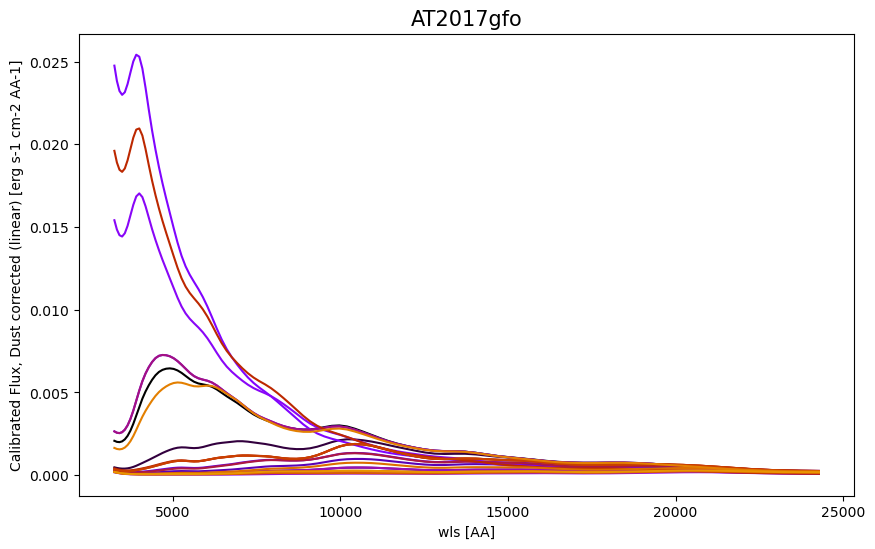

In [18]:
# FINAL host-corrected column in *_FINAL_spec.txt = linear F_lambda (not log10); y-scale accordingly.
def _path_FINAL_hostcorr(obj, l):
    """Primary: stem name matches TwoD extended (0.16..._FINAL_spec). Legacy: mangle spec_mjd filename."""
    base = obj.FINALspec_path
    p_stem = base + l.replace('spec_extended', 'FINAL_spec')
    if os.path.isfile(p_stem):
        return p_stem
    mpath = obj.results_mainpath + 'fitted_phot4mangling_%s.dat' % obj.snname
    if not os.path.isfile(mpath):
        return p_stem
    phot = pd.read_csv(mpath, sep='\t')
    fk = float(convert2mjd(l))
    n = len(phot)
    m = np.zeros(n, dtype=bool)
    if 'ext_grid_phase' in phot.columns:
        v = phot['ext_grid_phase'].values.astype(float)
        m |= np.isclose(v, fk, rtol=0.0, atol=1e-3, equal_nan=True)
        m |= np.isclose(np.round(v, 6), np.round(fk, 6), rtol=0.0, atol=0.0, equal_nan=True)
    sm = phot['spec_mjd'].values.astype(float)
    m |= sm == fk
    m |= np.isclose(sm, fk, rtol=0.0, atol=1e-3, equal_nan=True)
    if (not m.any()) and 'spec_log_phase' in phot.columns:
        slp = phot['spec_log_phase'].values.astype(float)
        m |= np.isclose(slp, fk, rtol=0.0, atol=1e-3, equal_nan=True)
    if m.any():
        smjd = float(phot.loc[m, 'spec_mjd'].values[0])
        p_mjd = base + '/%.6f_FINAL_spec.txt' % smjd
        if os.path.isfile(p_mjd):
            return p_mjd
    return p_stem

color = cycle(plt.cm.gnuplot(np.linspace(0,1,int(len(new_spec.get_spec_list())*1.2))))
fig = plt.figure(1, figsize=(10,6))
plt.title(new_spec.snname, fontsize=15)
mean, a = 1., 0
for l in new_spec.get_spec_list()[:]:
    new_spec.create_FINALspec_folder()
    pfin = _path_FINAL_hostcorr(new_spec, l)
    if not os.path.isfile(pfin):
        print('Missing FINAL:', pfin)
        continue
    sp = np.genfromtxt(pfin)
    plt.plot(sp[:,0], sp[:,1], lw=1.5, color=next(color))
    if mean == 1.:
        mean = np.median(sp[:,1]) * 0.2
    a = a + 1

plt.ylabel('Calibrated Flux, Dust corrected (linear) [erg s-1 cm-2 AA-1]')
plt.xlabel('wls [AA]')
plt.autoscale(True)
fig.savefig(new_spec.FINALspec_path + 'Final_Spec.png', bbox_inches='tight')
plt.show()
plt.close()

### SECOND: Remangle the "artificial" spectra (i.e. spectra that we extrapolated from the 2dim surface @phases were spectroscopy was too sparse)

In [19]:
#try for KN
new_spec = ReMangle_SingleSpectrumClass(
    snname=snname, twodim=True, spec_file=None, verbose=True
)
flagged_list = new_spec.get_FLAGGED_spec_list()
remangle_failed = []
remangle_diag_log_flagged = []
for f in flagged_list:
    new_spec = ReMangle_SingleSpectrumClass(
        snname=snname, twodim=True, spec_file=f, verbose=True
    )
    new_spec.load_extended_spec()
    result = new_spec.mangle_iteration_function()
    remangle_diag_log_flagged.append(getattr(new_spec, "remangle_diagnostics", None))
    if not result:
        remangle_failed.append(f)
        continue
    new_spec.save_FINAL_spectrum()
print("=" * 72)
n_flag = len(flagged_list)
print(
    "Re-mangle summary: %d / %d FLAGGED spectra could not be re-mangled (no in-MJD overlap)."
    % (len(remangle_failed), n_flag)
)
if remangle_failed:
    for _f in remangle_failed:
        print("  skipped:", _f)
print("=" * 72)

print_remangle_batch_summary(
    '"artificial" / FLAGGED extended spectra (get_FLAGGED_spec_list)',
    remangle_diag_log_flagged,
)


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']
self.spec_file 1.209050_spec_extended_FL.txt
[DEBUG] Starting mangling for: 1.209050_spec_extended_FL.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 3
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.97611828 0.92351038 1.5108592 ]
ratios normed: [-0.14136776 -0.18764374  0.3290115 ]
ratios err: [0.1

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 3
[remangle-diag] FAIL | max|ratio-1|=0.24268 (tol=0.01) | n_loop=0/0 | last_iter=0 | 1.209050_spec_extended_FL.txt
skipping plotting for now
[DEBUG] Saving final mangled spectrum
self.spec_file 1.372848_spec_extended_FL.txt
[DEBUG] Starting mangling for: 1.372848_spec_extended_FL.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 1
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.90291161]
ratios normed: [0.]
ratios err: [0.10842649]
ratios err normed: [0.12008538]
mean: 0.902911610657168
ConstantKernel(log_constant=-inf, ndim=1, axes=array([0])) * Matern32Kernel(metric=Metric(0.3, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None)
wls_eff_normedT: [2.39354305]
[DEBUG] Applying initial mangling mask
ratios 1
[remangle-iter] state=0 max|ratio-1|=2.2204e-16 mask_min=0.90291 mask_max=0.90291
ratios 1
[remangle-diag] PASS | max|ratio-1|=2.2204e-16 (tol=0.01) | n_loop=0/0 | last_iter=0 | 1.372848_spec_extended_FL.txt
skipping plotting for now
[DEBUG

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 25
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.99095871 0.89888854 1.08497445 1.51739471 1.00623624 0.85792282
 0.44317996 0.9583505  0.94131848 0.85946461 0.67725885 0.86033335
 0.79353532 1.11264157 0.89908591 0.98912456 0.99080498 0.80605351
 1.04735039 1.0088343  0.52260187 1.21083692 1.05804398 1.05444969
 1.11024703]
ratios normed: [ 0.04531989 -0.05180098  0.14449307  0.60063468  0.06143551 -0.09501397
 -0.53250844  0.01092288 -0.00704347 -0.0933876  -0.28558865 -0.09247121
 -0.16293358  0.17367792 -0.05159279  0.04338512  0.04515772 -0.14972869
  0.10480506  0.06417609 -0.44872968  0.27726     0.11608527  0.11229381
  0.17115203]
ratios err: [0.05082539 0.23459784 0.05798698 0.14691398 0.05261657 0.10345652
 0.17810252 0.22803676 0.11433969 0.13656893 0.11971485 0.69661031
 0.10097173 0.14360721 0.0528126  0.13710312 0.1098028  0.20877335
 0.04716244 0.03503229 0.08004877 0.24920555 0.05211494 0.03467302
 0.05213278]
ratios err normed: [0.05361353 0.2474

...

ratios 1
[remangle-diag] PASS | max|ratio-1|=1.1102e-16 (tol=0.01) | n_loop=0/0 | last_iter=0 | 1.319969_spec_extended_FL.txt
skipping plotting for now
[DEBUG] Saving final mangled spectrum
self.spec_file 1.181295_spec_extended_FL.txt
[DEBUG] Starting mangling for: 1.181295_spec_extended_FL.txt
[DEBUG] Calling calculate_ratios4mangling (initial)
ratios 3
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [1.0027906  0.96652962 1.40347371]
ratios normed: [-0.10804756 -0.14030062  0.24834817]
ratios err: [0.15955775 0.07309976 0.39347468]
ratios err normed: [0.14192188 0.06502007 0.34998404]
mean: 1.1242646422345155
ConstantKernel(log_constant=-3.473388034625442, ndim=1, axes=array([0])) * Matern32Kernel(metric=Metric(0.3, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None)
wls_eff_normedT: [2.4007484  2.38253745 1.00286734]
[DEBUG] Applying initial mangling mask
ratios 3
[remangle-iter] state=0 max|ratio-1|=0.19716 mask_min=0.98855 mask_max=1.1735
ratios 3
[remangle-diag

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 8
[remangle-iter] state=0 max|ratio-1|=0.31936 mask_min=0.86407 mask_max=1.332
ratios 8
[remangle-diag] FAIL | max|ratio-1|=0.31936 (tol=0.01) | n_loop=0/0 | last_iter=0 | 1.055901_spec_extended_FL.txt
skipping plotting for now
[DEBUG] Saving final mangled spectrum
self.spec_file 0.405091_spec_extended_FL.txt
[DEBUG] Starting mangling for: 0.405091_spec_extended_FL.txt
[DEBUG] Calling calculate_ratios4mangling (initial)


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_ext_spec['flux'], cut_ext_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:526: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_ext_spec['fluxerr'])**2,
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/783562861.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_97144/1712292565.py:523: RuntimeWarning: invalid value 

ratios 40
[DEBUG] Calling GP_interpolation_mangle (initial)
ratios: [0.90842783 0.92543634 1.06457467 1.00913538 0.48850815 0.89195576
 1.01057854 0.84118372 0.89292167 0.99195794 1.08953827 0.99186091
 1.14364107 0.84924005 0.95974242 0.89239786 0.95826799 0.94633217
 1.12331997 0.84004937 1.02451905 0.82569793 0.8966225  0.99244712
 0.93455544 0.96918627 1.20669326 1.04094039 1.00400019 1.01441655
 0.99857783 1.09608014 0.93708531 1.03655708 1.61098545 1.02755486
 1.17713138 0.97398088 0.91779392 1.07590525]
ratios normed: [-0.08192784 -0.06473877  0.07587673  0.01984887 -0.5063056  -0.09857479
  0.02130735 -0.14988586 -0.09759863  0.00248907  0.10110536  0.00239101
  0.15578254 -0.14174399 -0.03006847 -0.09812799 -0.03155856 -0.04362109
  0.1352457  -0.15103224  0.03539586 -0.16553604 -0.0938585   0.00298344
 -0.05552285 -0.02052436  0.21950412  0.05199154  0.01465917  0.02518611
  0.00917924  0.10771668 -0.05296612  0.04756169  0.62808848  0.0384639
  0.1896284  -0.01567885 -0.0724

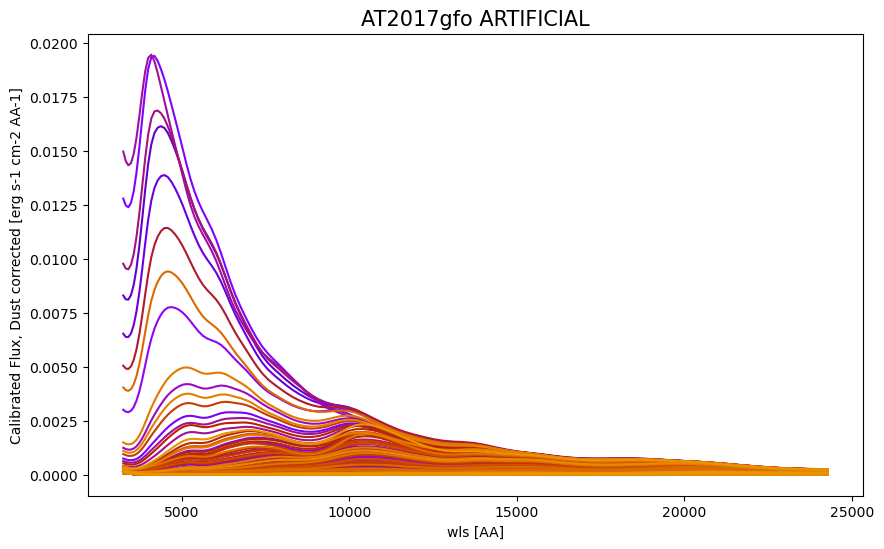

Not plotted (11 file(s), re-mangle skipped and/or no FINAL on disk):
  -1.458607_spec_extended_FL.txt
  -2.958607_spec_extended_FL.txt
  -1.004672_spec_extended_FL.txt
  -2.458607_spec_extended_FL.txt
  -0.706063_spec_extended_FL.txt
  -1.958607_spec_extended_FL.txt
  -0.530782_spec_extended_FL.txt
  -0.406249_spec_extended_FL.txt
  -1.708607_spec_extended_FL.txt
  -2.708607_spec_extended_FL.txt
  -2.208607_spec_extended_FL.txt


In [14]:
import os
new_spec.create_FINALspec_folder()
missing_final = []
_remap_ok = True
try:
    _remangle_failed = set(remangle_failed)
    _flagged = list(flagged_list)
except NameError:
    _remap_ok = False
    _remangle_failed = set()
    _flagged = new_spec.get_FLAGGED_spec_list()[:]
    print("Note: 'flagged_list' / 'remangle_failed' not in scope. "
          "Re-run the FLAGGED re-mangle cell so only successful re-mangles are listed as 'plotted' vs 'not plotted'.")

plot_list = [f for f in _flagged if f not in _remangle_failed]
if (not _remap_ok) and plot_list:
    # Only use extended names that have a matching FINAL on disk
    _exists = []
    for f in plot_list:
        pth = os.path.join(
            new_spec.FINALspec_path,
            f.replace("_spec_extended_FL.txt", "_FINAL_spec_FL.txt"),
        )
        if os.path.exists(pth):
            _exists.append(f)
    plot_list = _exists

nplt = max(1, len(plot_list))
color = cycle(plt.cm.gnuplot(np.linspace(0, 1, int(nplt * 1.2))))
fig = plt.figure(1, figsize=(10, 6))
plt.title(snname + " ARTIFICIAL", fontsize=15)
mean = 1.0
a = 0
for l in plot_list:
    final_name = l.replace("_spec_extended_FL.txt", "_FINAL_spec_FL.txt")
    pth = os.path.join(new_spec.FINALspec_path, final_name)
    if not os.path.exists(pth):
        missing_final.append(l)
        continue
    sp = np.genfromtxt(pth)
    plt.plot(
        sp[:, 0], sp[:, 1],
        lw=1.5, color=next(color),
    )
    if mean == 1.0:
        mean = np.median(sp[:, 1]) * 0.2
plt.ylabel("Calibrated Flux, Dust corrected [erg s-1 cm-2 AA-1]")
plt.xlabel("wls [AA]")
#plt.ylim(0, 10)
plt.autoscale(True)
fig.savefig(new_spec.FINALspec_path + "Final_Spec_FL.png", bbox_inches="tight")
plt.show()
plt.close()
not_plotted = []
if _remap_ok:
    for f in _remangle_failed:
        not_plotted.append(f)
    not_plotted.extend(missing_final)
else:
    for f in _flagged:
        p = os.path.join(
            new_spec.FINALspec_path,
            f.replace("_spec_extended_FL.txt", "_FINAL_spec_FL.txt"),
        )
        if not os.path.exists(p):
            not_plotted.append(f)
    not_plotted.extend(missing_final)
if not_plotted:
    from collections import OrderedDict
    uniq = list(OrderedDict.fromkeys(not_plotted))
    print("=" * 72)
    print("Not plotted (%d file(s), re-mangle skipped and/or no FINAL on disk):" % len(uniq))
    for fn in uniq:
        print(" ", fn)
    print("=" * 72)
elif len(plot_list) == 0:
    print("No FINAL Spec FL curves to plot (check re-mangle outputs).")
else:
    print("Plotted %d curve(s) (all entries from the re-mangle success list had a FINAL file)." % len(plot_list))


In [12]:
# --- FINAL spectra from notebook 6 extended only (no RE_mangle / GP iteration) ---
# Run after rimangle imports + ``ReMangle_SingleSpectrumClass`` cell (uses ``snname`` and knobs above).
#
# Writes the same FINAL tree as ``save_FINAL_spectrum()`` (HostCorr, HostNotCorr, as_observed) from
# in-memory extended linear flux; ``final_mangled_spec`` is an identity copy of ``ext_spec_linear``.

from remangle_identity import wire_final_mangled_spec_from_extended_linear

_floor = float(globals().get("REMANGLE_FLUX_FLOOR", 0.0))

_probe = ReMangle_SingleSpectrumClass(snname, twodim=True, spec_file=None)
_default_specs = list(_probe.get_spec_list())
_fl_specs = list(_probe.get_FLAGGED_spec_list())
spec_batch = sorted(set(_default_specs) | set(_fl_specs))
print(
    "FINAL-from-extended only: %d files (%d *_spec_extended.txt + %d *_spec_extended_FL.txt, union) under %s"
    % (
        len(spec_batch),
        len(_default_specs),
        len(_fl_specs),
        getattr(_probe, "extended_files_path", "?"),
    )
)


for fname in spec_batch:
    obj = ReMangle_SingleSpectrumClass(
        snname,
        twodim=True,
        spec_file=fname,
        extended_flux_in_log10=None,
        save_flux_in_log10=True,
    )
    obj.load_extended_spec()
    wire_final_mangled_spec_from_extended_linear(obj, _floor)
    obj.save_FINAL_spectrum()
    print("saved FINAL for %s -> %s" % (fname, obj.FINALspec_path))


Choose one spec_file from this list:
['0.165363_spec_extended.txt', '0.387568_spec_extended.txt', '0.873437_spec_extended.txt', '0.736556_spec_extended.txt', '0.647970_spec_extended.txt', '0.158665_spec_extended.txt', '-0.309582_spec_extended.txt', '-0.274105_spec_extended.txt', '1.020030_spec_extended.txt', '0.872381_spec_extended.txt', '0.158664_spec_extended.txt', '0.653898_spec_extended.txt', '0.539351_spec_extended.txt', '-0.293965_spec_extended.txt', '0.537315_spec_extended.txt', '0.537316_spec_extended.txt', '0.927986_spec_extended.txt', '0.976442_spec_extended.txt', '0.810367_spec_extended.txt', '0.181958_spec_extended.txt', '0.927249_spec_extended.txt']
FINAL-from-extended only: 266 files (21 *_spec_extended.txt + 245 *_spec_extended_FL.txt, union) under /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/twodim_ryanv2/extrapolate/full_gp/
self.spec_file -0.028729_spec_extended_FL.txt
saved FINAL for -0.028729_spec_extended_FL.txt -> /Users/ravkaur/